# DIPSHIFT Fitter

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [108]:
#%% Functions for powder averaging    
class PowderAverage():
    def __init__(self,n_gamma=256,sym=True):
        """
        Powder average
        """
        if sym:
            beta=np.linspace(0,90,51)[1:]
            weight=np.sin(beta*np.pi/180)
            alpha=np.zeros(beta.shape)
        else:
            alpha=[]
            beta=[]
            weight=[]
            with open('rep144.txt','r') as f:
                for line in f:
                    a,b,w=line.strip().split()
                    alpha.append(float(a))
                    beta.append(float(b))
                    weight.append(float(w))

        self.alpha=np.repeat(alpha,n_gamma)*np.pi/180
        self.beta=np.repeat(beta,n_gamma)*np.pi/180
        self.weight=np.repeat(weight,n_gamma)
        self.weight/=self.weight.sum()
        self.gamma=np.tile(np.linspace(0,2*np.pi,n_gamma,endpoint=False),len(alpha))

        self.ca=np.cos(self.alpha)
        self.sa=np.sin(self.alpha)
        self.cb=np.cos(self.beta)
        self.sb=np.sin(self.beta)
        self.cg=np.cos(self.gamma)
        self.sg=np.sin(self.gamma)

        self.all=self.ca,self.sa,self.cb,self.sb,self.cg,self.sg

        self.N=len(self.ca)

In [109]:
def d2(c,s,m=None,mp=0):
    """
    Calculates components of the d2 matrix. By default only calculates the components
    starting at mp=0 and returns five components, from -2,-1,0,1,2. One may also
    edit the starting component and select a specific final component 
    (mp=None returns all components, whereas mp may be specified between -2 and 2)
    
    d2_m_mp=d2(m,mp,c,s)  #c and s are the cosine and sine of the desired beta angle
    
        or
        
    d2_m_mp=d2(m,mp,beta) #Give the angle directly
    
    Setting mp to None will return all values for mp in a 2D array
    
    (Note that m is the final index)
    """
    
    """
    Here we define each of the components as functions. We'll collect these into
    an array, and then call them out with the m and mp indices
    """
    "First, for m=-2"
    
    if m is None or mp is None:
        assert m is not None or mp is not None,"m or mp must be specified"
        if m is None:
            index=range((mp+2)*5,(mp+3)*5)
        elif mp is None:
            index=range(m+2,25,5)
    else:
        index=[(mp+2)*5+(m+2)]
    
    out=list()    
    for i in index:
        #mp=-2
        if i==0:x=0.25*(1+c)**2
        if i==1:x=0.5*(1+c)*s
        if i==2:x=np.sqrt(3/8)*s**2
        if i==3:x=0.5*(1-c)*s
        if i==4:x=0.25*(1-c)**2
        #mp=-1
        if i==5:x=-0.5*(1+c)*s
        if i==6:x=c**2-0.5*(1-c)
        if i==7:x=np.sqrt(3/8)*2*c*s
        if i==8:x=0.5*(1+c)-c**2
        if i==9:x=0.5*(1-c)*s
        #mp=0
        if i==10:x=np.sqrt(3/8)*s**2
        if i==11:x=-np.sqrt(3/8)*2*s*c
        if i==12:x=0.5*(3*c**2-1)
        if i==13:x=np.sqrt(3/8)*2*s*c
        if i==14:x=np.sqrt(3/8)*s**2
        #mp=1
        if i==15:x=-0.5*(1-c)*s
        if i==16:x=0.5*(1+c)-c**2
        if i==17:x=-np.sqrt(3/8)*2*s*c
        if i==18:x=c**2-0.5*(1-c)
        if i==19:x=0.5*(1+c)*s
        #mp=2
        if i==20:x=0.25*(1-c)**2
        if i==21:x=-0.5*(1-c)*s
        if i==22:x=np.sqrt(3/8)*s**2
        if i==23:x=-0.5*(1+c)*s
        if i==24:x=0.25*(1+c)**2
        out.append(x)
        
    if m is None or mp is None:
        return np.array(out)
    else:
        return out[0]

def D2(pwdavg=None,alpha=None,beta=None,gamma=None,m=None,mp=0):
    """
    Calculates components of the D2 matrix. By default only calculates the components
    starting at m=0 and returns five components, from -2,-1,0,1,2. One may also
    edit the starting component and select a specific final component 
    (mp=None returns all components, whereas mp may be specified between -2 and 2)
    
    d2_m_mp=d2(ca,sa,cb,sb,cg,sg,m,mp)  #c and s are the cosine and sine of the alpha,beta,gamma angle
    
        or
        
    d2_m_mp=d2(m,mp,beta) #Give the angle directly
    
    Setting mp to None will return all values for mp in a 2D array
    
    (Note that m is the final index)
    """
    
    if pwdavg is None:
        ca,sa,cb,sb,cg,sg=np.cos(alpha),np.sin(alpha),np.cos(beta),np.sin(beta),np.cos(gamma),np.sin(gamma)
    else:
        ca,sa,cb,sb,cg,sg=pwdavg.all

    if m is None:
        p0=(ca-1j*sa*np.sign(mp))**np.abs(mp)
        p=cg-1j*sg
        phase=np.array([p**m for m in range(-2,3)])*p0
    elif mp is None:
        p0=(cg-1j*sg*np.sign(m))**np.abs(m)
        p=ca-1j*sa
        phase=np.array([p**mp for mp in range(-2,3)])*p0
    else:
        phase=((ca-1j*sa*np.sign(mp))**np.abs(mp))*((cg-1j*sg*np.sign(m))**np.abs(m))
        
    return (d2(cb,sb,m,mp)*phase).T


In [110]:
dHC=21500*2
tetra=np.arccos(-1/3)
cm=np.sqrt(1/3)
sm=np.sqrt(2/3)
    
class DIPSHIFT():
    def __init__(self,nH:int=1,sym:bool=True,vr:float=5000,N:int=17,dHX=dHC,LG=False,n_gamma:int=256):
        self.LG=LG
        self._dHX=dHX

        self.pwdavg=PowderAverage(n_gamma=n_gamma,sym=True)  
        self.n_gamma=n_gamma

        self.sym=sym
        self.nH=nH
        self.N=N
        self.vr=vr

        self._xt=None
        self._exp=None
        self._tau=None

    @property
    def dHX(self):
        return self._dHX*(np.sqrt(1/3) if self.LG else 1)
    
    @property
    def APAS(self):
        return np.array([0,0,np.sqrt(3/2),0,0])
    
    @property
    def nH(self):
        return self._nH
        
    @nH.setter
    def nH(self,nH):
        assert nH in [1,2,3],'nH must be 1, 2, or 3'
        
        self._nH=nH
        
        if self.sym or self.nH:
            Azz_lab=(d2(cm,-sm,mp=None,m=0)*D2(self.pwdavg,mp=0,m=None)).T[[0,1,3,4]]/2
            self.Azz=np.array([Azz_lab.T]).repeat(self.nH,axis=0)
        else:
            Azz=[]
            for k in range(nH):
                AMF=D2(alpha=0,beta=tetra,gamma=2*np.pi/3*k,mp=0,m=None)/2
                Azz_lab=np.array([d2(cm,sm,mp=m,m=0)*D2(self.pwdavg,mp=None,m=m)@AMF for m in [-2,-1,1,2]])
                Azz.append(Azz_lab.T)
            self.Azz=np.array(Azz)
        
    @property
    def tau(self):
        self._tau=np.arange(self.N)*1/(self.vr*(self.N-1))
        return self._tau

    @property
    def exp(self):
        if self._exp is None:
            self._exp=np.array([1j/(q*2*np.pi*self.vr)*(np.exp(-1j*q*self.tau*2*np.pi*self.vr)-1) for q in [-2,-1,1,2]]).T
        return self._exp

    @property
    def xt(self):
        if self._xt is None:
            self._xt=np.array([[(Azz0*exp0).sum(-1).real for Azz0 in self.Azz] for exp0 in self.exp],dtype=float)
        return self._xt

    def I(self,S,T2=None):
        omegat=np.cos(2*np.pi*self.dHX*S*self.xt)
        I=(omegat.prod(1)*self.pwdavg.weight).sum(-1)
        if T2 is not None:
            I*=np.exp(-self.tau/T2)
        return I

    def plot(self,S,T2=None,ax=None):
        if ax is None:ax=plt.subplots()[1]
                    
        ax.plot(self.tau*self.vr,self.I(S=S,T2=T2))
        ax.set_xlabel(r'$\tau*\nu_r$')

        ax.set_ylim([min([0,ax.get_ylim()[0]]),max([1,ax.get_ylim()[1]])])
        return ax

    def __call__(self,S,T2=None):
        return self.I(S=S,T2=T2)
    

<Axes: xlabel='$\\tau*\\nu_r$'>

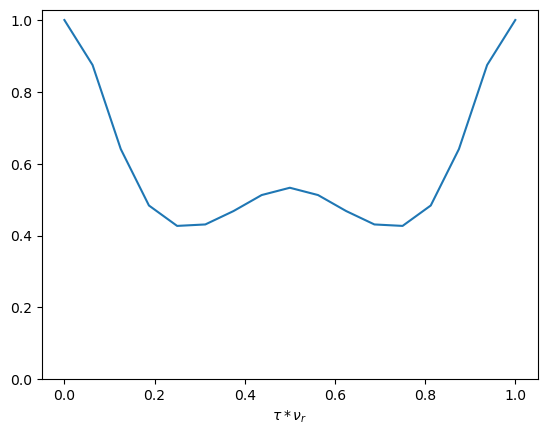

In [113]:
DIPSHIFT(nH=2,sym=False,vr=1000).plot(S=.1)

In [343]:
ds=DIPSHIFT(sym=False,nH=3)

-0.05014867202398231

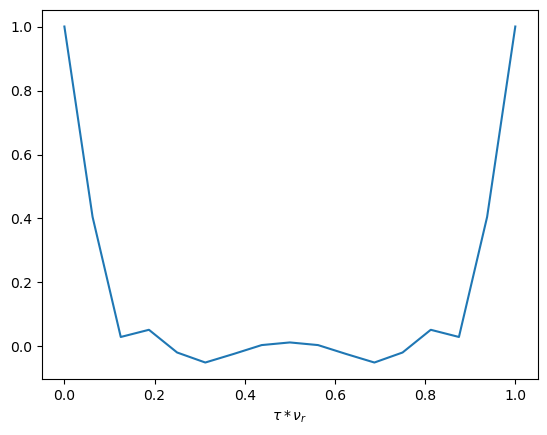

In [344]:
ds.plot(S=1)
ds(S=1).min()

In [335]:
ds.Azz[0][:10]

array([[-0.10549123-0.00733497j, -0.00442899+0.12754882j,
        -0.00442899-0.12754882j, -0.10549123+0.00733497j],
       [-0.10500425-0.01250234j, -0.00755786+0.12740171j,
        -0.00755786-0.12740171j, -0.10500425+0.01250234j],
       [-0.10426431-0.0176396j , -0.01068218+0.12717786j,
        -0.01068218-0.12717786j, -0.10426431+0.0176396j ],
       [-0.10327318-0.02273436j, -0.01380006+0.1268774j ,
        -0.01380006-0.1268774j , -0.10327318+0.02273436j],
       [-0.10203326-0.02777435j, -0.01690963+0.12650052j,
        -0.01690963-0.12650052j, -0.10203326+0.02777435j],
       [-0.10054754-0.03274743j, -0.02000902+0.12604744j,
        -0.02000902-0.12604744j, -0.10054754+0.03274743j],
       [-0.09881958-0.03764162j, -0.02309635+0.12551843j,
        -0.02309635-0.12551843j, -0.09881958+0.03764162j],
       [-0.09685356-0.04244512j, -0.02616977+0.12491381j,
        -0.02616977-0.12491381j, -0.09685356+0.04244512j],
       [-0.09465422-0.04714637j, -0.02922743+0.12423395j,
      